# HW08 Part B :: Anomaly Detection using Convolutional Autoencoder

COSC 6373 -- Adam Nelson-Archer, 2140122


## Prerequisites

- Install packages if needed:
  - `pip install -U tensorflow matplotlib numpy pandas scikit-learn kagglehub`
- Dataset reference (assignment):
  - https://www.kaggle.com/datasets/alxmamaev/flowers-recognition?select=flowers
- Reference notebook to match visual flow:
  - https://gist.githubusercontent.com/JudeWells/7deae1bec3eb581b210829e906811bdc/raw/3613510a809f26e484bcac121a9825cb60acf50f/CNN_Autoencoder_Anomaly_Detection.ipynb
- Supporting article:
  - https://medium.com/@judewells/image-anomaly-detection-novelty-detection-using-convolutional-auto-encoders-in-keras-1c31321c10f2

In [1]:
from pathlib import Path
import random

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.neighbors import KernelDensity

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.1


In [2]:
# Download and locate the Flowers dataset from Kaggle.
download_root = Path(kagglehub.dataset_download("alxmamaev/flowers-recognition"))
cfg_data_root = download_root / "flowers"

cfg_img_size = (96, 96)
cfg_batch_size = 32
cfg_epochs = 80  # not 600; early stopping keeps runtime practical
cfg_learning_rate = 1.0  # for Adadelta setup used below

# Part B requirement: train autoencoder on sunflower images.
cfg_normal_class = "sunflower"

if not cfg_data_root.exists():
    raise FileNotFoundError(f"Dataset folder not found: {cfg_data_root}")

all_classes = sorted([p.name for p in cfg_data_root.iterdir() if p.is_dir()])
if cfg_normal_class not in all_classes:
    raise ValueError(f"{cfg_normal_class} not found in {all_classes}")

anomaly_classes = [c for c in all_classes if c != cfg_normal_class]
print("Dataset root:", cfg_data_root)
print("Classes:", all_classes)
print("Normal class:", cfg_normal_class)
print("Anomaly classes:", anomaly_classes)

Dataset root: C:\Users\Adam\.cache\kagglehub\datasets\alxmamaev\flowers-recognition\versions\2\flowers
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Normal class: sunflower
Anomaly classes: ['daisy', 'dandelion', 'rose', 'tulip']


In [3]:
def list_images(folder: Path) -> list[Path]:
    exts = {".jpg", ".jpeg", ".png"}
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in exts])


def split_three_way(paths: list[Path], train_frac: float = 0.7, val_frac: float = 0.15, seed: int = 42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(paths))
    rng.shuffle(idx)
    paths = [paths[i] for i in idx]

    n = len(paths)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train = paths[:n_train]
    val = paths[n_train:n_train + n_val]
    test = paths[n_train + n_val:]
    return train, val, test


normal_paths = list_images(cfg_data_root / cfg_normal_class)
normal_train_paths, normal_val_paths, normal_test_paths = split_three_way(normal_paths, 0.7, 0.15, SEED)

anomaly_test_paths: dict[str, list[Path]] = {}
for cls in anomaly_classes:
    cls_paths = list_images(cfg_data_root / cls)
    _, _, cls_test = split_three_way(cls_paths, 0.7, 0.15, SEED)
    anomaly_test_paths[cls] = cls_test

print("Sunflower train/val/test:", len(normal_train_paths), len(normal_val_paths), len(normal_test_paths))
for cls in anomaly_classes:
    print(f"{cls} test:", len(anomaly_test_paths[cls]))

Sunflower train/val/test: 513 109 111
daisy test: 116
dandelion test: 159
rose test: 119
tulip test: 149


In [4]:
def decode_and_resize(path: tf.Tensor, img_size: tuple[int, int]):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape((img_size[0], img_size[1], 3))
    return img


def make_autoencoder_ds(paths: list[Path], img_size: tuple[int, int], batch_size: int, shuffle: bool):
    ds = tf.data.Dataset.from_tensor_slices([str(p) for p in paths])
    if shuffle:
        ds = ds.shuffle(buffer_size=max(1000, len(paths)), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p: decode_and_resize(p, img_size), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x: (x, x), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_autoencoder_ds(normal_train_paths, cfg_img_size, cfg_batch_size, shuffle=True)
val_ds = make_autoencoder_ds(normal_val_paths, cfg_img_size, cfg_batch_size, shuffle=False)

print(train_ds)
print(val_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None))>


In [5]:
def build_conv_autoencoder_like_reference(img_size: tuple[int, int]):
    inp = tf.keras.Input(shape=(img_size[0], img_size[1], 3), name="image")

    # Encoder layout matching the reference notebook style.
    x = tf.keras.layers.Conv2D(16, (3, 3), activation="relu", padding="same", name="enc_conv1")(inp)
    x = tf.keras.layers.MaxPooling2D((4, 4), padding="same", name="enc_pool1")(x)

    x = tf.keras.layers.Conv2D(8, (3, 3), activation="relu", padding="same", name="enc_conv2")(x)
    x = tf.keras.layers.MaxPooling2D((4, 4), padding="same", name="enc_pool2")(x)

    x = tf.keras.layers.Conv2D(3, (3, 3), activation="relu", padding="same", name="enc_conv3")(x)
    encoded = tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="encoded")(x)  # 3x3x3

    # Decoder layout matching reference style (upsampling blocks).
    x = tf.keras.layers.Conv2D(3, (3, 3), activation="relu", padding="same", name="dec_conv1")(encoded)
    x = tf.keras.layers.UpSampling2D((2, 2), name="dec_up1")(x)

    x = tf.keras.layers.Conv2D(8, (3, 3), activation="relu", padding="same", name="dec_conv2")(x)
    x = tf.keras.layers.UpSampling2D((4, 4), name="dec_up2")(x)

    x = tf.keras.layers.Conv2D(16, (3, 3), activation="relu", padding="same", name="dec_conv3")(x)
    x = tf.keras.layers.UpSampling2D((4, 4), name="dec_up3")(x)

    out = tf.keras.layers.Conv2D(3, (3, 3), activation="sigmoid", padding="same", name="reconstruction")(x)

    autoencoder = tf.keras.Model(inp, out, name="conv_autoencoder")
    encoder = tf.keras.Model(inp, encoded, name="encoder_replica")
    return autoencoder, encoder


autoencoder, encoder = build_conv_autoencoder_like_reference(cfg_img_size)
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adadelta(learning_rate=1.0),
    loss="mse",
)
print("Autoencoder summary:")
autoencoder.summary()
print("\nEncoder summary (compressed 3x3x3):")
encoder.summary()

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 24, 24, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 48, 48, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 96, 96, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - loss: 0.0940 - val_loss: 0.0759
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - loss: 0.0739 - val_loss: 0.0680
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - loss: 0.0661 - val_loss: 0.0659
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - loss: 0.0620 - val_loss: 0.0614
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - loss: 0.0550 - val_loss: 0.0436
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - loss: 0.0392 - val_loss: 0.0375
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - loss: 0.0325 - val_loss: 0.0381
Epoch 8/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - loss: 0.0305 - val_loss: 0.0287
Epoch 9/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - loss: 0.0259 - val_loss: 0.0252
Epoch 10/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - loss: 0.0228 - val_loss: 0.0234
Epoch 11/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - loss: 0.0214 - val_loss: 0.0223
Epoch 12/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step

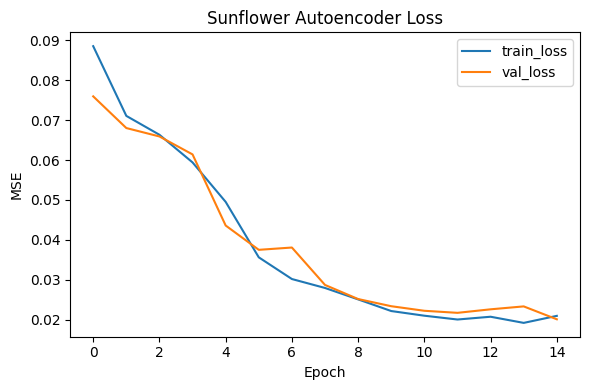

In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
]

history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=cfg_epochs,
    callbacks=callbacks,
    verbose=1,
)

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Sunflower Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()

## Requirement 1: Original vs Reconstructed (Sunflower)

In [ ]:
batch = next(iter(val_ds))[0]
recon = autoencoder.predict(batch[:6], verbose=0)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    axes[0, i].imshow(batch[i])
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(np.clip(recon[i], 0, 1))
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()

## Requirement 2: Reconstruction Error (same style as reference)

First, print validation (normal) vs anomaly reconstruction errors, then compare MSE distributions by flower type.

In [ ]:
def load_array(paths: list[Path], img_size: tuple[int, int]) -> np.ndarray:
    arr = []
    for p in paths:
        b = tf.io.read_file(str(p))
        img = tf.image.decode_image(b, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0
        arr.append(img.numpy())
    return np.asarray(arr, dtype=np.float32)


def reconstruction_mse(model: tf.keras.Model, x: np.ndarray, batch_size: int = 64) -> np.ndarray:
    recon = model.predict(x, batch_size=batch_size, verbose=0)
    return np.mean((x - recon) ** 2, axis=(1, 2, 3))


# Normal train/validation/test arrays
x_train = load_array(normal_train_paths, cfg_img_size)
x_val = load_array(normal_val_paths, cfg_img_size)
x_norm_test = load_array(normal_test_paths, cfg_img_size)

# Per-class anomaly arrays
x_anomaly_by_class: dict[str, np.ndarray] = {}
for cls in anomaly_classes:
    x_anomaly_by_class[cls] = load_array(anomaly_test_paths[cls], cfg_img_size)

# Aggregate anomaly array (for reference-style error print)
x_anomaly_all = np.concatenate([x_anomaly_by_class[c] for c in anomaly_classes], axis=0)

val_error_mean = float(np.mean(reconstruction_mse(autoencoder, x_val)))
anomaly_error_mean = float(np.mean(reconstruction_mse(autoencoder, x_anomaly_all)))
print(f"Error on validation set: {val_error_mean:.6f}, error on anomaly set: {anomaly_error_mean:.6f}")

# Requirement comparison by flower type
mse_by_class: dict[str, np.ndarray] = {cfg_normal_class: reconstruction_mse(autoencoder, x_norm_test)}
for cls in anomaly_classes:
    mse_by_class[cls] = reconstruction_mse(autoencoder, x_anomaly_by_class[cls])

summary_rows = []
for cls, values in mse_by_class.items():
    summary_rows.append(
        {
            "class": cls,
            "mean_mse": float(np.mean(values)),
            "std_mse": float(np.std(values)),
            "median_mse": float(np.median(values)),
            "n": len(values),
        }
    )

mse_summary_df = pd.DataFrame(summary_rows).sort_values("mean_mse")
mse_summary_df

In [ ]:
plt.figure(figsize=(8, 4.5))
for cls in [cfg_normal_class] + anomaly_classes:
    plt.hist(mse_by_class[cls], bins=35, alpha=0.5, label=cls)
plt.title("Reconstruction MSE Distribution by Flower Type")
plt.xlabel("MSE")
plt.ylabel("count")
plt.legend()
plt.tight_layout()

## Requirement 3: Density Score Distributions (reference-style visuals)

We follow the same visual approach as the reference notebook:
- one combined histogram for training normal, validation normal, and anomalies,
- plus per-flower anomaly comparisons for the assignment requirement.

In [ ]:
# Encoded vectors (3x3x3 -> flatten to 27) in reference notebook style
z_train = encoder.predict(x_train, batch_size=64, verbose=0)
z_val = encoder.predict(x_val, batch_size=64, verbose=0)
z_anomaly_all = encoder.predict(x_anomaly_all, batch_size=64, verbose=0)

z_train_flat = z_train.reshape(len(z_train), -1)
z_val_flat = z_val.reshape(len(z_val), -1)
z_anomaly_all_flat = z_anomaly_all.reshape(len(z_anomaly_all), -1)

kde = KernelDensity(kernel="gaussian", bandwidth=0.2)
kde.fit(z_train_flat)

training_density_scores = kde.score_samples(z_train_flat)
validation_density_scores = kde.score_samples(z_val_flat)
anomaly_density_scores = kde.score_samples(z_anomaly_all_flat)

print("Encoded shape:", z_train.shape, "-> flat size", z_train_flat.shape[1])

# Keep per-flower scores for assignment requirement
anomaly_density_by_class: dict[str, np.ndarray] = {}
for cls in anomaly_classes:
    z_cls = encoder.predict(x_anomaly_by_class[cls], batch_size=64, verbose=0)
    anomaly_density_by_class[cls] = kde.score_samples(z_cls.reshape(len(z_cls), -1))

density_rows = [
    {
        "split_or_class": "sunflower_train",
        "mean_log_density": float(np.mean(training_density_scores)),
        "std_log_density": float(np.std(training_density_scores)),
        "median_log_density": float(np.median(training_density_scores)),
        "n": len(training_density_scores),
    },
    {
        "split_or_class": "sunflower_val",
        "mean_log_density": float(np.mean(validation_density_scores)),
        "std_log_density": float(np.std(validation_density_scores)),
        "median_log_density": float(np.median(validation_density_scores)),
        "n": len(validation_density_scores),
    },
    {
        "split_or_class": "all_anomalies",
        "mean_log_density": float(np.mean(anomaly_density_scores)),
        "std_log_density": float(np.std(anomaly_density_scores)),
        "median_log_density": float(np.median(anomaly_density_scores)),
        "n": len(anomaly_density_scores),
    },
]

for cls in anomaly_classes:
    vals = anomaly_density_by_class[cls]
    density_rows.append(
        {
            "split_or_class": cls,
            "mean_log_density": float(np.mean(vals)),
            "std_log_density": float(np.std(vals)),
            "median_log_density": float(np.median(vals)),
            "n": len(vals),
        }
    )

density_summary_df = pd.DataFrame(density_rows).sort_values("mean_log_density", ascending=False)
density_summary_df

In [ ]:
# 1) Reference-style combined density distribution plot
plt.figure(figsize=(10, 5))
plt.title("Distribution of Density Scores")
plt.hist(training_density_scores, bins=12, alpha=0.5, label="Training Normal")
plt.hist(validation_density_scores, bins=12, alpha=0.5, label="Validation Normal")
plt.hist(anomaly_density_scores, bins=12, alpha=0.5, label="Anomalies")
plt.xlabel("Density Score")
plt.ylabel("count")
plt.legend(loc="upper right")
plt.tight_layout()

# 2) Assignment-required per-flower density comparisons
for cls in anomaly_classes:
    plt.figure(figsize=(7.5, 4.2))
    plt.hist(training_density_scores, bins=40, alpha=0.45, label="sunflower_train")
    plt.hist(validation_density_scores, bins=40, alpha=0.45, label="sunflower_val")
    plt.hist(anomaly_density_by_class[cls], bins=40, alpha=0.55, label=f"{cls}_anomaly")
    plt.title(f"Density Scores: sunflower train/val vs {cls}")
    plt.xlabel("log density (KDE on latent vectors)")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()

## Requirement 4: How the Autoencoder Works for Anomaly Detection

The autoencoder is trained only on sunflower images, so it learns a compact latent representation specialized for sunflower structure, color, and texture. During inference, sunflower images are typically reconstructed with lower error, while non-sunflower flowers are reconstructed less accurately, producing higher MSE. This reconstruction gap is used as an anomaly signal.

Using latent-space density adds a second anomaly signal: if an encoded sample falls in a low-density region compared with sunflower training encodings, it is likely novel/anomalous. In this notebook, anomaly-like classes generally show lower log-density than sunflower train/validation encodings.

## Requirement 5: Other Methods Besides Autoencoders

- **One-Class SVM:** Learns a boundary around normal data and flags outside points as anomalies.
- **Isolation Forest:** Random partitioning isolates anomalies faster because they are rare and different.
- **Local Outlier Factor (LOF):** Uses local neighborhood density to detect points with unusually low local density.
- **Deep SVDD / One-Class Deep Methods:** Trains a network to map normal data near a compact center.
- **GAN-based anomaly detection (e.g., AnoGAN variants):** Uses generator/discriminator mismatch as anomaly evidence.
- **Diffusion or energy-based methods:** Estimates normal data likelihood/energy and flags unlikely samples.

## Acknowledgment

I used a coding assistant (GPT-5.3-Codex) to help scaffold and organize this notebook.